<div style="
    background-color:#4A4A4A;
    padding:25px;
    border-radius:12px;
    text-align:center;
    border:3px solid #D4AF37;
    box-shadow:0px 4px 10px rgba(0,0,0,0.2);
">

<h1 style="
    color:#D4AF37;
    font-family:Georgia, serif;
    margin-bottom:8px;
">
📊 Canteen Sales Exploratory Data Analysis (EDA)
</h1>

<h2 style="
    color:#F5F5F5;
    font-size:18px;
    margin:0;
">
<b> By:</b> Rimsha Pervaiz
</h2>

</div>

# **Canteen Sale Exploratory Data Analysis (EDA)**

## What is EDA?
It is the process of understanding, cleaning, and exploring a dataset before performing advanced analysis or building machine learning models.

**🎯 Key Goals of Exploratory Data Analysis (EDA)**
 - 📌 Understand the structure and characteristics of the dataset.
 - 📌 Identify missing values and duplicate records.
 - 📌 Detect outliers and data inconsistencies.
 - 📌 Summarize data using descriptive statistics.
 - 📌 Explore relationships between variables.
 - 📌 Discover patterns, trends, and distributions.
 - 📌 Prepare clean and reliable data for further analysis or modeling.
 - 📌 Generate meaningful insights to support data-driven decisions.

## Problem Statement
![](Image.jpeg)

## Import and Setup

In [37]:
# packages for 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set seaborn style for plots
sns.set_style('darkgrid')

# configure random seed
np.random.seed(42)

# ignore warning
import warnings as w
w.filterwarnings('ignore')

# print time stamp
import time
print(f"Last Update: {time.asctime()}")


Last Update: Thu Jul 30 10:43:05 2026


## Load CSV file into Pandas DataFrame

In [7]:
# read csv
df = pd.read_csv('canteen_sales_100_records.csv')

In [8]:
# print header 2 rows
df.head(2)

,Bill_ID,Date,Time,Customer_Type,Item,Category,Quantity,Unit_Price,Total_Amount,Payment_Method
0,B001,2026-07-15,12:15,Trainer,Tea,Beverage,5,120,600,EasyPaisa
1,B002,2026-07-17,09:45,Student,Juice,Beverage,2,180,360,JazzCash


## 1. Data Overview

### 1.1 How many rows and columns are in the dataset?

In [9]:
df.shape

(100, 10)

> There are 100 rows in 10 columns

### 1.2 list all columns and their data types

In [11]:
df.columns

Index(['Bill_ID', 'Date', 'Time', 'Customer_Type', 'Item', 'Category',
       'Quantity', 'Unit_Price', 'Total_Amount', 'Payment_Method'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Bill_ID         100 non-null    str  
 1   Date            100 non-null    str  
 2   Time            100 non-null    str  
 3   Customer_Type   100 non-null    str  
 4   Item            100 non-null    str  
 5   Category        100 non-null    str  
 6   Quantity        100 non-null    int64
 7   Unit_Price      100 non-null    int64
 8   Total_Amount    100 non-null    int64
 9   Payment_Method  100 non-null    str  
dtypes: int64(3), str(7)
memory usage: 7.9 KB


In [9]:
df.dtypes

Bill_ID             str
Date                str
Time                str
Customer_Type       str
Item                str
Category            str
Quantity          int64
Unit_Price        int64
Total_Amount      int64
Payment_Method      str
dtype: object

> The dataset contains **10 columns**, including **7 categorical (string)** variables and **3 numerical (integer)** variables, which are suitable for both descriptive and statistical analysis.

### 1.3 Check for missing values. Which columns have missing data?

In [12]:
df.isnull().sum()

Bill_ID           0
Date              0
Time              0
Customer_Type     0
Item              0
Category          0
Quantity          0
Unit_Price        0
Total_Amount      0
Payment_Method    0
dtype: int64


>The dataset was examined for missing values, and **no missing values were found** in any column. This indicates that the dataset is complete and suitable for analysis without requiring any data imputa
tion or cleaning for missing records.

| ✅ Column Name | Missing Values |
|:--------------|---------------:|
| Bill_ID | 0 |
| Date | 0 |
| Time | 0 |
| Customer_Type | 0 |
| Item | 0 |
| Category | 0 |
| Quantity | 0 |
| Unit_Price | 0 |
| Total_Amount | 0 |
| Payment_Method | 0 |

> **💡 Observation:** All **10 columns** contain complete data with **0 missing values**, ensuring high data quality for Exploratory Data Analysis (EDA).

### 1.4 Are there any duplicate records? If yes, how many?

In [13]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


>The dataset was examined for duplicate records, and **no duplicate records were found**. This indicates that each transaction is unique, ensuring the dataset is reliable and free from redundant entries.

| ✅ Analysis | Result |
|:------------|-------:|
| Duplicate Records | 0 |

> **💡 Observation:** The dataset contains **0 duplicate records**, confirming that all transactions are unique and the data is clean and ready for accurate Exploratory Data Analysis (EDA).

## 2. Basic Statistics

### 2.1 What is the total revenue generated?

In [14]:
print("total Revenue :", df["Total_Amount"].sum())

total Revenue : 56100


💰 Revenue Dashboard

| 📊 KPI | 📈 Value |
|:-------|---------:|
| **Total Revenue Generated** | **Rs. 56,100** |

> ✅ **Business Insight:** The canteen earned **Rs. 56,100** in total sales, representing the overall financial performance of the dataset.

### 2.2 What are the average, minimum, and maximum values of **Total_Amount**?

In [15]:
df["Total_Amount"].agg(["mean", "min", "max"])

mean     561.0
min       60.0
max     2250.0
Name: Total_Amount, dtype: float64

>The **Total_Amount** column was analyzed to understand the distribution of transaction values. The results show an **average transaction amount of Rs. 561.00**, with the **minimum bill amount of Rs. 60.00** and the **maximum bill amount of Rs. 2,250.00**.

| 📊 Statistic | Amount (Rs.) |
|:-------------|-------------:|
| **Average (Mean)** | **561.00** |
| **Minimum** | **60.00** |
| **Maximum** | **2,250.00** |

> **💡 Observation:** Most transactions revolve around an average bill of **Rs. 561.00**, while transaction values range from **Rs. 60.00** to **Rs. 2,250.00**, indicating a wide variation in customer spending.

### 2.3. What is the average quantity sold per transaction?

In [16]:
df["Quantity"].mean()

np.float64(2.82)

> 📦 **Transaction Analysis:**  
> Each customer purchases an average of **2.82 items** per transaction, indicating that most sales consist of multiple-item purchases rather than single-item orders.

| 📦 Quantity Statistics | Value |
|:-----------------------|------:|
| **Average Quantity Sold** | **2.82 Items** |

> **💡 Key Finding:** An average of nearly **3 items per transaction** suggests opportunities for bundle offers and promotional deals to further increase sales.

### 2.4. Which payment method has the highest number of transactions?

In [17]:
df["Payment_Method"].value_counts()

Payment_Method
Cash         33
EasyPaisa    25
JazzCash     22
Card         20
Name: count, dtype: int64

| 📊 Payment Method | 📈 Transactions |
|:------------------|---------------:|
| Cash | **33** |
| EasyPaisa | 25 |
| JazzCash | 22 |
| Card | 20 |

> ✅ **Key Finding:** Cash is the most commonly used payment method with **33 transactions**, followed by EasyPaisa, JazzCash, and Card.

## 3. Sale Analysis

### 3.1 Which item is the best-selling (by quantity)?

In [18]:
df.groupby('Item')['Quantity'].sum().sort_values(ascending = False)

Item
Tea            51
Fries          46
Samosa         38
Burger         36
Cake           26
Coffee         25
Juice          25
Sandwich       16
Water          14
Pizza Slice     5
Name: Quantity, dtype: int64

>The sales quantity of each item was analyzed to identify the most popular products. **Tea** emerged as the **best-selling item** with **51 units sold**, followed by **Fries (46)** and **Samosa (38)**, while **Pizza Slice** recorded the lowest sales with **5 units**.

| 🛒 Item | Quantity Sold |
|:--------|--------------:|
| ☕ **Tea** | **51** |
| 🍟 Fries | 46 |
| 🥟 Samosa | 38 |
| 🍔 Burger | 36 |
| 🍰 Cake | 26 |
| ☕ Coffee | 25 |
| 🧃 Juice | 25 |
| 🥪 Sandwich | 16 |
| 💧 Water | 14 |
| 🍕 Pizza Slice | 5 |

> **💡 Observation:** **Tea** is the most demanded product in the canteen, while **Pizza Slice** has the lowest sales. Promoting low-selling items through discounts or combo offers may help improve their sales performance.

### 3.2 Which item is the best-selling (by quantity)?

In [19]:
df.groupby("Item")["Total_Amount"].sum().sort_values(ascending=False)

Item
Burger         16200
Fries           9200
Tea             6120
Coffee          5500
Cake            5200
Juice           4500
Sandwich        4000
Samosa          3040
Pizza Slice     1500
Water            840
Name: Total_Amount, dtype: int64

>The revenue generated by each item was analyzed to identify the highest-earning products. **Burger** generated the **highest revenue of Rs. 16,200**, followed by **Fries (Rs. 9,200)** and **Tea (Rs. 6,120)**. **Water** generated the lowest revenue with **Rs. 840**.

| 🍔 Item | 💰 Revenue (Rs.) |
|:--------|-----------------:|
| 🍔 **Burger** | **16,200** |
| 🍟 Fries | 9,200 |
| ☕ Tea | 6,120 |
| ☕ Coffee | 5,500 |
| 🍰 Cake | 5,200 |
| 🧃 Juice | 4,500 |
| 🥪 Sandwich | 4,000 |
| 🥟 Samosa | 3,040 |
| 🍕 Pizza Slice | 1,500 |
| 💧 Water | 840 |

> **💡 Observation:** **Burger** is the highest revenue-generating item, contributing significantly to the canteen's overall sales. In contrast, **Water** generates the least revenue, indicating lower profitability or demand.

### 3.3 Which category has the highest sales (by total amount)?

In [20]:
df.groupby("Category")["Total_Amount"].sum().sort_values(ascending=False)

Category
Fast Food    17700
Beverage     16960
Snack        16240
Dessert       5200
Name: Total_Amount, dtype: int64

>The sales revenue was analyzed across all product categories to identify the highest-performing category. **Fast Food** generated the **highest revenue of Rs. 17,700**, followed closely by **Beverage (Rs. 16,960)** and **Snack (Rs. 16,240)**. **Dessert** contributed the lowest revenue with **Rs. 5,200**.

| 🍽️ Category | 💰 Total Revenue (Rs.) |
|:------------|-----------------------:|
| 🍔 **Fast Food** | **17,700** |
| 🥤 Beverage | 16,960 |
| 🥟 Snack | 16,240 |
| 🍰 Dessert | 5,200 |

> **💡 Observation:** **Fast Food** is the highest revenue-generating category, making it the canteen's strongest product segment. **Dessert** records the lowest sales, suggesting an opportunity for promotional offers or product improvements to increase its revenue.

### 3.4 What is the total revenue generated by each category?

In [21]:
df.groupby("Category")["Total_Amount"].sum()

Category
Beverage     16960
Dessert       5200
Fast Food    17700
Snack        16240
Name: Total_Amount, dtype: int64

>The total revenue for each product category was calculated to evaluate its contribution to overall sales. **Fast Food** generated the highest revenue of **Rs. 17,700**, followed by **Beverage (Rs. 16,960)** and **Snack (Rs. 16,240)**, while **Dessert** contributed **Rs. 5,200**.

| 🍽️ Category | 💰 Total Revenue (Rs.) |
|:------------|-----------------------:|
| 🥤 Beverage | 16,960 |
| 🍰 Dessert | 5,200 |
| 🍔 **Fast Food** | **17,700** |
| 🥟 Snack | 16,240 |

> **💡 Observation:** **Fast Food** is the largest contributor to the canteen's total revenue, whereas **Dessert** generates the lowest revenue. Focusing on high-performing categories while promoting lower-performing ones can help maximize overall sales.

## 4. Customer Analysis

### 4.1 Which customer type spends the most (by total amount)?

In [22]:
df.groupby("Customer_Type")["Total_Amount"].sum().sort_values(ascending=False)

Customer_Type
Visitor    21730
Student    21120
Trainer    13250
Name: Total_Amount, dtype: int64

>The spending patterns of different customer types were analyzed to determine their contribution to total revenue. **Visitors** recorded the **highest spending of Rs. 21,730**, followed closely by **Students (Rs. 21,120)**, while **Trainers** contributed **Rs. 13,250**.

| 👥 Customer Type | 💰 Total Spending (Rs.) |
|:-----------------|------------------------:|
| 👤 **Visitor** | **21,730** |
| 🎓 Student | 21,120 |
| 👨‍🏫 Trainer | 13,250 |

> **💡 Observation:** **Visitors** are the highest-spending customer group, contributing the largest share of revenue. **Students** also make a significant contribution, whereas **Trainers** account for the lowest overall spending.

### 4.2 Which customer type has the highest number of transactions?

In [23]:
df["Customer_Type"].value_counts()

Customer_Type
Visitor    38
Student    33
Trainer    29
Name: count, dtype: int64

>The transaction frequency was analyzed to identify the most active customer group. **Visitors** recorded the **highest number of transactions (38)**, followed by **Students (33)** and **Trainers (29)**.

| 👥 Customer Type | 🧾 Number of Transactions |
|:-----------------|--------------------------:|
| 👤 **Visitor** | **38** |
| 🎓 Student | 33 |
| 👨‍🏫 Trainer | 29 |

> **💡 Observation:** **Visitors** are the most active customer group with **38 transactions**, indicating that they visit the canteen more frequently than Students and Trainers.

### 4.3 What is the average spending per customer type?

In [24]:
df.groupby("Customer_Type")["Total_Amount"].mean()

Customer_Type
Student    640.000000
Trainer    456.896552
Visitor    571.842105
Name: Total_Amount, dtype: float64

>The average spending per transaction was analyzed for each customer type to understand purchasing behavior. **Students** recorded the **highest average spending of Rs. 640.00**, followed by **Visitors (Rs. 571.84)**, while **Trainers** had the **lowest average spending of Rs. 456.90**.

| 👥 Customer Type | 💰 Average Spending (Rs.) |
|:-----------------|--------------------------:|
| 🎓 **Student** | **640.00** |
| 👤 Visitor | 571.84 |
| 👨‍🏫 Trainer | 456.90 |

> **💡 Observation:** **Students** spend the most on average per transaction, suggesting they make higher-value purchases, whereas **Trainers** have the lowest average spending among all customer groups.

## Task 5: Time-Based analysis

In [25]:
df.head(1)

,Bill_ID,Date,Time,Customer_Type,Item,Category,Quantity,Unit_Price,Total_Amount,Payment_Method
0,B001,2026-07-15,12:15,Trainer,Tea,Beverage,5,120,600,EasyPaisa


### 5.1 :Which date generated the highest revenue?

In [26]:
df.groupby("Date")["Total_Amount"].sum().sort_values(ascending=False).head(1)

Date
2026-07-05    4320
Name: Total_Amount, dtype: int64

> Date *2026-07-05* has highest revenue generated

### 5.2: Which day has the highest sales?

In [27]:
# Convert the data type of dare col
df['Date'] = pd.to_datetime(df['Date'])

In [28]:
# extract the week day from date and save as a new feature
df['Week_Day'] = df['Date'].dt.day_name()

In [29]:
df.groupby('Week_Day')['Total_Amount'].sum().sort_values(ascending=False)

Week_Day
Friday       10200
Sunday        9470
Wednesday     8930
Tuesday       8560
Monday        7720
Thursday      7620
Saturday      3600
Name: Total_Amount, dtype: int64

>The analysis shows that **Friday** generated the highest total sales, with a revenue of **10,200**. This indicates that customer activity was highest on Fridays, making it the busiest sales day of the week.

### 5.3: At what hour do most transactions occur?

In [31]:
df['Time'] = pd.to_datetime(df['Time'] , format = '%H;%M')

ValueError: time data "12:15" doesn't match format "%H;%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [32]:
df['Hour'] = df['Time'].dt.hour

AttributeError: Can only use .dt accessor with datetimelike values

In [33]:
df.groupby('Hour')['Total_Amount'].sum().sort_values(ascending = False)

KeyError: 'Hour'

>The hourly sales analysis shows that **8:00 AM** generated the highest total sales, with a revenue of **8,960**. This indicates that the canteen experiences its busiest sales period early in the morning, likely due to customers purchasing breakfast or morning refreshments.

In [34]:
df["Time"] = pd.to_datetime(df["Time"])

df["Hour"] = df["Time"].dt.hour

hourly = df["Hour"].value_counts().sort_index()

print(hourly)

Hour
8     12
9     12
10     8
11     7
12     9
13     9
14    14
15     7
16    12
17    10
Name: count, dtype: int64


### 5.4: How does total revenue change over time?

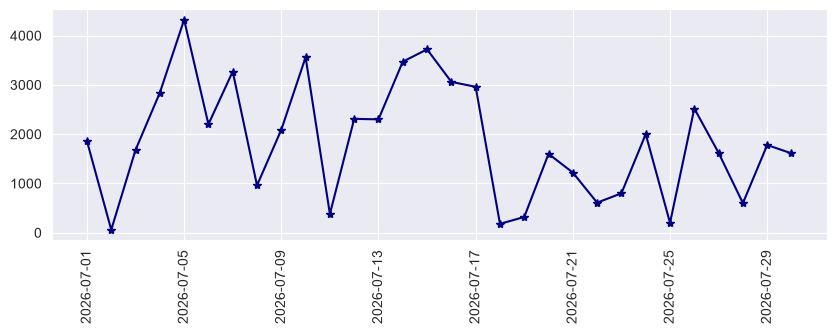

In [35]:
trend = df.groupby("Date")["Total_Amount"].sum()
plt.figure(figsize=(10,3))
plt.plot(trend.keys(), trend, marker = '*', color='navy')
plt.xticks(rotation = 'vertical')

plt.show()

## Task 6: Visualization

### 6.1:Total Sales by Category

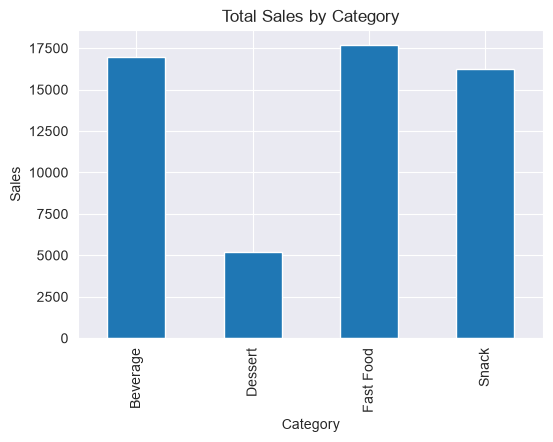

In [36]:
category_sales = df.groupby("Category")["Total_Amount"].sum()

category_sales.plot(kind="bar",
                    figsize=(6,4),
                    title="Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

### 6.2

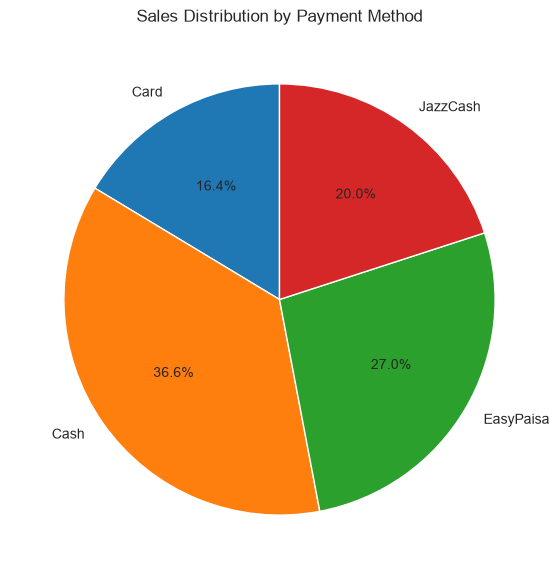

In [39]:
payment_sales = df.groupby("Payment_Method")["Total_Amount"].sum()

plt.figure(figsize=(7,7))
plt.pie(payment_sales,
        labels=payment_sales.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Sales Distribution by Payment Method")
plt.savefig("Pie_Chart.png")
plt.show()

### 6.3

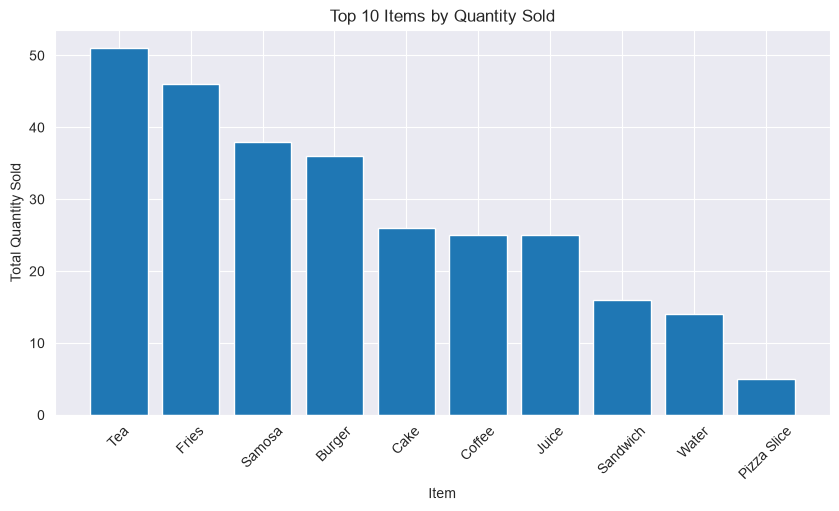

In [41]:
top_items = df.groupby("Item")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_items.index, top_items.values)

plt.title("Top 10 Items by Quantity Sold")
plt.xlabel("Item")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.savefig("6.3_chart.png")
plt.show()

### 6.4

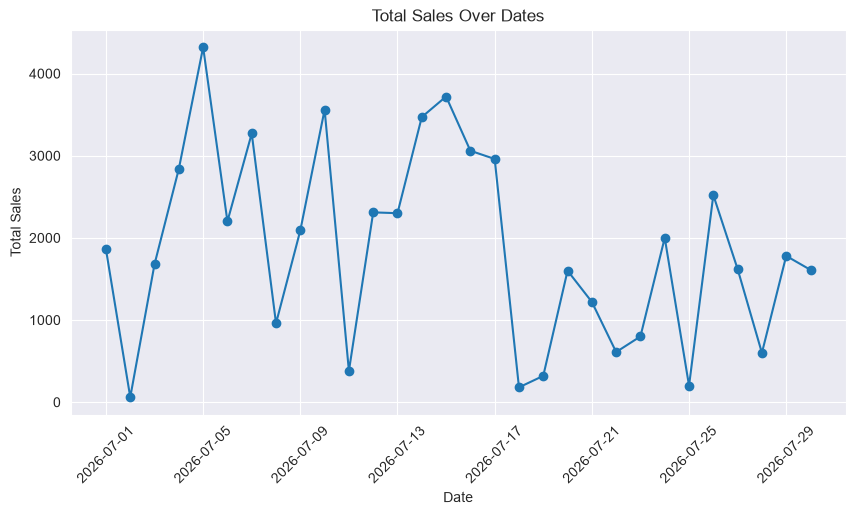

In [43]:
df["Date"] = pd.to_datetime(df["Date"])

daily_sales = df.groupby("Date")["Total_Amount"].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_sales.index,
         daily_sales.values,
         marker='o')

plt.title("Total Sales Over Dates")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig("6.4.png")
plt.show()

### 6.5

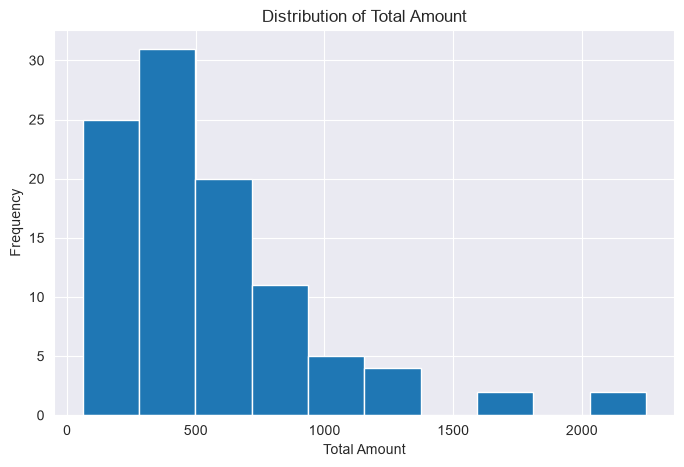

In [45]:
plt.figure(figsize=(8,5))
plt.hist(df["Total_Amount"], bins=10)

plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.savefig("6.5.png")
plt.show()

### 6.6

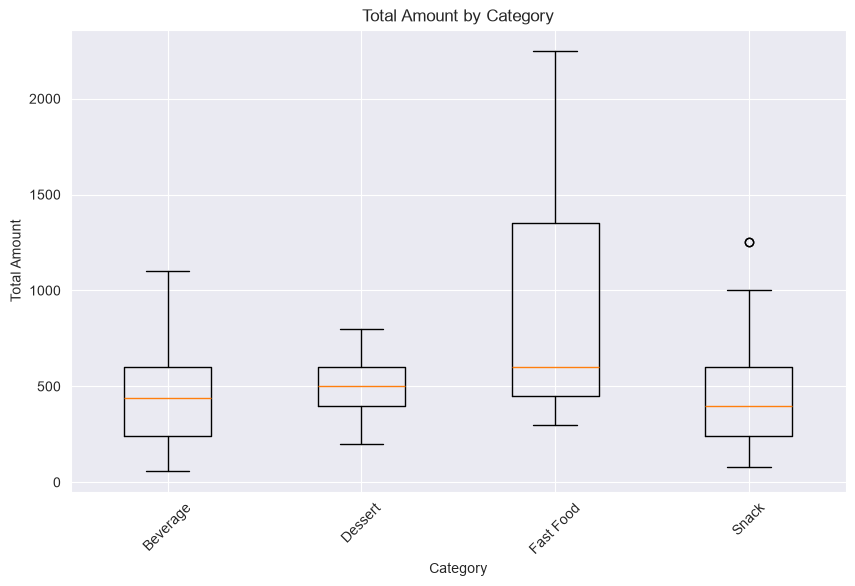

In [48]:
plt.figure(figsize=(10,6))

categories = df["Category"].unique()

data = [df[df["Category"] == cat]["Total_Amount"] for cat in categories]

plt.boxplot(data, tick_labels=categories)

plt.title("Total Amount by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.savefig("6.6.png")
plt.show()

## 7. Comparative Analysis

### 7.1

Payment_Method
Card          9180
Cash         20550
EasyPaisa    15150
JazzCash     11220
Name: Total_Amount, dtype: int64


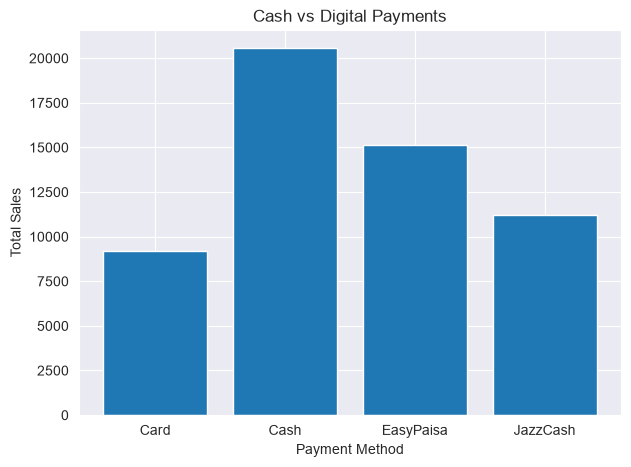

In [49]:
payment_sales = df.groupby("Payment_Method")["Total_Amount"].sum()

print(payment_sales)

plt.figure(figsize=(7,5))
plt.bar(payment_sales.index, payment_sales.values)

plt.title("Cash vs Digital Payments")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")

plt.show()

### 7.2

Day_Type
Weekday    43030
Weekend    13070
Name: Total_Amount, dtype: int64


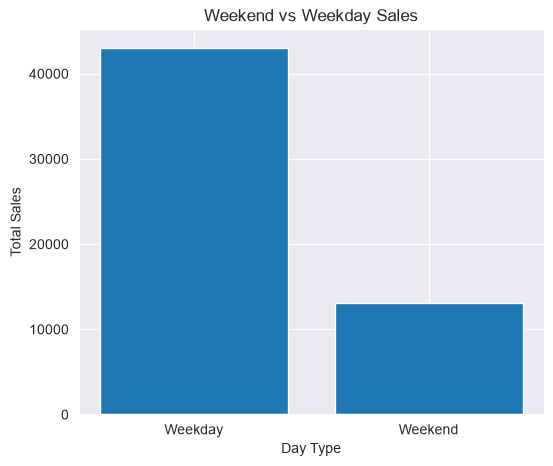

In [50]:
df["Date"] = pd.to_datetime(df["Date"])

df["Day"] = df["Date"].dt.day_name()

df["Day_Type"] = df["Day"].apply(
    lambda x: "Weekend" if x in ["Saturday","Sunday"] else "Weekday"
)

sales = df.groupby("Day_Type")["Total_Amount"].sum()

print(sales)

plt.figure(figsize=(6,5))
plt.bar(sales.index, sales.values)

plt.title("Weekend vs Weekday Sales")
plt.xlabel("Day Type")
plt.ylabel("Total Sales")

plt.show()

## 7.3

Category
Beverage     458.378378
Dessert      520.000000
Fast Food    931.578947
Snack        477.647059
Name: Total_Amount, dtype: float64


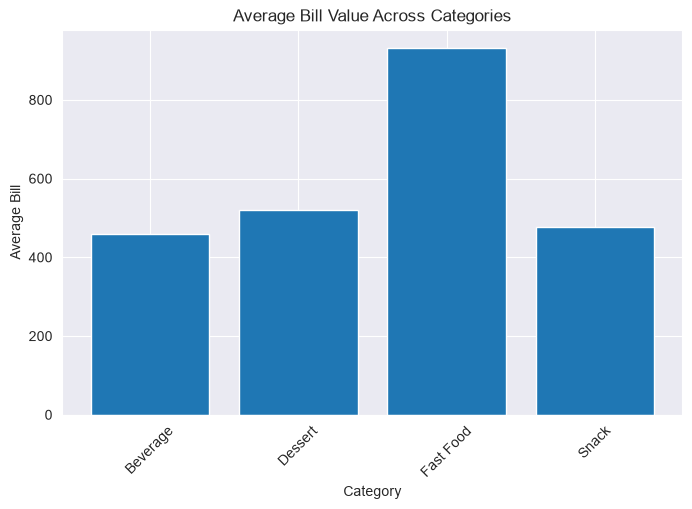

In [51]:
avg_bill = df.groupby("Category")["Total_Amount"].mean()

print(avg_bill)

plt.figure(figsize=(8,5))
plt.bar(avg_bill.index, avg_bill.values)

plt.title("Average Bill Value Across Categories")
plt.xlabel("Category")
plt.ylabel("Average Bill")

plt.xticks(rotation=45)

plt.show()

## 8. Insights & Business Questions

### 8.1

In [52]:
print("Top 5 Best Selling Items")
print(df.groupby("Item")["Quantity"].sum().sort_values(ascending=False).head())

print("\nHighest Revenue Category")
print(df.groupby("Category")["Total_Amount"].sum().sort_values(ascending=False).head(1))

print("\nMost Preferred Payment Method")
print(df["Payment_Method"].value_counts().head(1))

print("\nCustomer Type Spending")
print(df.groupby("Customer_Type")["Total_Amount"].sum())

print("\nHighest Sales Date")
print(df.groupby("Date")["Total_Amount"].sum().sort_values(ascending=False).head(1))

Top 5 Best Selling Items
Item
Tea       51
Fries     46
Samosa    38
Burger    36
Cake      26
Name: Quantity, dtype: int64

Highest Revenue Category
Category
Fast Food    17700
Name: Total_Amount, dtype: int64

Most Preferred Payment Method
Payment_Method
Cash    33
Name: count, dtype: int64

Customer Type Spending
Customer_Type
Student    21120
Trainer    13250
Visitor    21730
Name: Total_Amount, dtype: int64

Highest Sales Date
Date
2026-07-05    4320
Name: Total_Amount, dtype: int64


### 8.2

In [53]:
top_items = df.groupby("Item")["Total_Amount"].sum().sort_values(ascending=False)

top_categories = df.groupby("Category")["Total_Amount"].sum().sort_values(ascending=False)

print("Top 5 Revenue Generating Items")
print(top_items.head())

print("\nTop Categories")
print(top_categories.head())

Top 5 Revenue Generating Items
Item
Burger    16200
Fries      9200
Tea        6120
Coffee     5500
Cake       5200
Name: Total_Amount, dtype: int64

Top Categories
Category
Fast Food    17700
Beverage     16960
Snack        16240
Dessert       5200
Name: Total_Amount, dtype: int64


### 8.3

In [55]:
low_items = df.groupby("Item")["Total_Amount"].sum().sort_values()

low_categories = df.groupby("Category")["Total_Amount"].sum().sort_values()

print("Lowest Revenue Items")
print(low_items.head())

print("\nLowest Revenue Categories")
print(low_categories.head())

Lowest Revenue Items
Item
Water           840
Pizza Slice    1500
Samosa         3040
Sandwich       4000
Juice          4500
Name: Total_Amount, dtype: int64

Lowest Revenue Categories
Category
Dessert       5200
Snack        16240
Beverage     16960
Fast Food    17700
Name: Total_Amount, dtype: int64


## 9. Advanced Analysis

### 9.1

Correlation: 0.5855024595491138


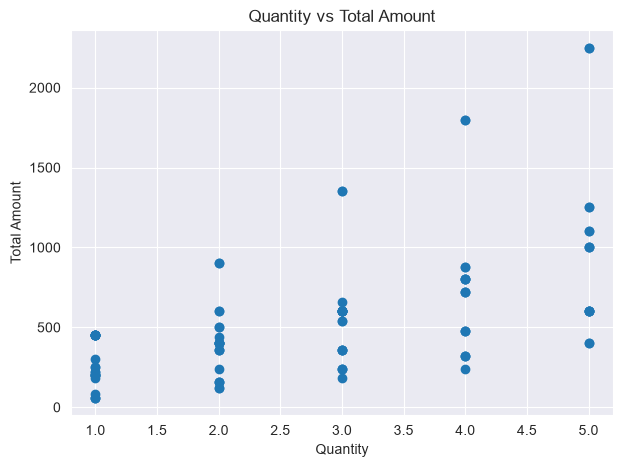

In [56]:
correlation = df["Quantity"].corr(df["Total_Amount"])

print("Correlation:", correlation)

plt.figure(figsize=(7,5))
plt.scatter(df["Quantity"], df["Total_Amount"])

plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")

plt.show()

### 9.2

Spending_Level
Medium    39
Low       36
High      25
Name: count, dtype: int64


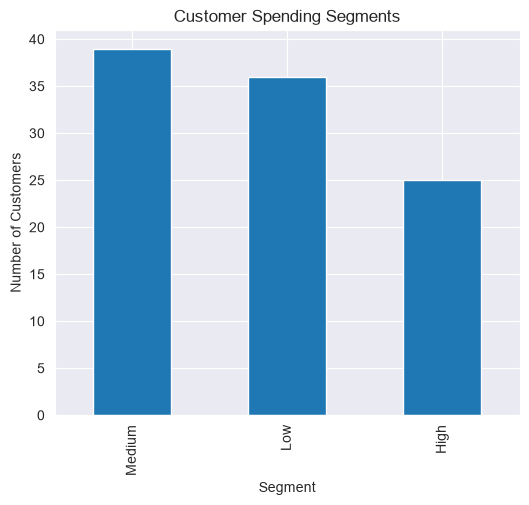

In [58]:
df["Spending_Level"] = pd.qcut(
    df["Total_Amount"],
    q=3,
    labels=["Low","Medium","High"]
)

print(df["Spending_Level"].value_counts())

plt.figure(figsize=(6,5))
df["Spending_Level"].value_counts().plot(kind="bar")

plt.title("Customer Spending Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

### 9.3

In [59]:
Q1 = df["Total_Amount"].quantile(0.25)
Q3 = df["Total_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Total_Amount"] < lower) | (df["Total_Amount"] > upper)]

print("Number of Outliers:", len(outliers))

outliers

Number of Outliers: 8


,Bill_ID,Date,Time,Customer_Type,Item,Category,Quantity,Unit_Price,Total_Amount,Payment_Method,Week_Day,Hour,Day,Day_Type,Spending_Level
4,B005,2026-07-07,2026-07-30 16:45:00,Visitor,Burger,Fast Food,5,450,2250,EasyPaisa,Tuesday,16,Tuesday,Weekday,High
22,B023,2026-07-10,2026-07-30 08:15:00,Visitor,Burger,Fast Food,3,450,1350,Cash,Friday,8,Friday,Weekday,High
23,B024,2026-07-01,2026-07-30 08:15:00,Student,Sandwich,Snack,5,250,1250,Cash,Wednesday,8,Wednesday,Weekday,High
27,B028,2026-07-14,2026-07-30 15:30:00,Trainer,Burger,Fast Food,5,450,2250,JazzCash,Tuesday,15,Tuesday,Weekday,High
30,B031,2026-07-12,2026-07-30 14:45:00,Visitor,Burger,Fast Food,3,450,1350,EasyPaisa,Sunday,14,Sunday,Weekend,High
39,B040,2026-07-04,2026-07-30 17:00:00,Student,Sandwich,Snack,5,250,1250,EasyPaisa,Saturday,17,Saturday,Weekend,High
52,B053,2026-07-26,2026-07-30 09:30:00,Student,Burger,Fast Food,4,450,1800,Cash,Sunday,9,Sunday,Weekend,High
84,B085,2026-07-06,2026-07-30 08:45:00,Student,Burger,Fast Food,4,450,1800,Cash,Monday,8,Monday,Weekday,High


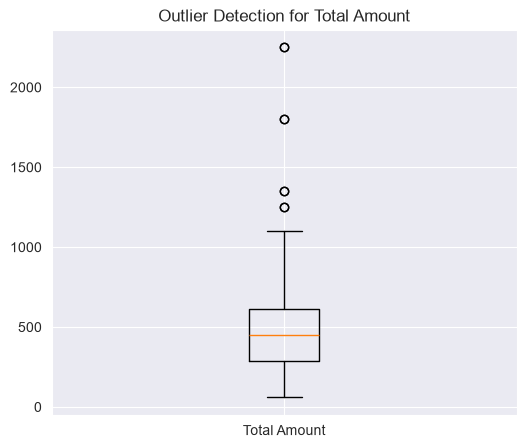

In [61]:
plt.figure(figsize=(6,5))

plt.boxplot(df["Total_Amount"], tick_labels=["Total Amount"])

plt.title("Outlier Detection for Total Amount")

plt.show()